In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score

In [ ]:
def softmax(z):
    z = z - np.max(z, axis=1, keepdims=True)
    exp_z = np.exp(z)
    return exp_z / np.sum(exp_z, axis=1, keepdims=True)

In [ ]:
def predict_softmax(X, W, b):

    z = np.dot(X, W) + b
    probs = softmax(z)

    predicted_classes = np.argmax(probs, axis=1)

    return predicted_classes

In [ ]:
def loss_softmax(y_pred, y):

    epsilon = 1e-15
    y_pred = np.clip(y_pred, epsilon, 1 - epsilon)

    loss = -np.sum(y * np.log(y_pred)) / y.shape[0]

    return loss

In [ ]:
def cost_softmax(X, y, W, b):

    n = X.shape[0]

    z = np.dot(X, W) + b
    y_pred = softmax(z)

    total_loss = -np.sum(y * np.log(y_pred))

    return total_loss / n

In [ ]:
def compute_gradient_softmax(X, y, W, b):

    n = X.shape[0]

    z = np.dot(X, W) + b
    y_pred = softmax(z)

    grad_W = np.dot(X.T, (y_pred - y)) / n
    grad_b = np.sum(y_pred - y, axis=0) / n

    return grad_W, grad_b

In [ ]:
def gradient_descent_softmax(X, y, W, b, alpha, n_iter, show_cost=False):

    cost_history = []

    for i in range(n_iter):

        grad_W, grad_b = compute_gradient_softmax(X, y, W, b)

        W = W - alpha * grad_W
        b = b - alpha * grad_b

        cost = cost_softmax(X, y, W, b)
        cost_history.append(cost)

        if show_cost and i % 100 == 0:
            print("Iteration", i, "Cost:", cost)

    return W, b, cost_history

In [ ]:
def load_and_prepare_mnist(csv_file):

    df = pd.read_csv(csv_file)

    y = df.iloc[:,0].values
    X = df.iloc[:,1:].values

    X = X / 255.0

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42
    )

    return X_train, X_test, y_train, y_test

In [ ]:
X_train, X_test, y_train, y_test = load_and_prepare_mnist("mnist.csv")

encoder = OneHotEncoder(sparse_output=False)

y_train = encoder.fit_transform(y_train.reshape(-1,1))
y_test = encoder.transform(y_test.reshape(-1,1))

d = X_train.shape[1]
c = y_train.shape[1]

W = np.random.randn(d,c)*0.01
b = np.zeros(c)

alpha = 0.1
n_iter = 1000

W_opt, b_opt, cost_history = gradient_descent_softmax(
    X_train, y_train, W, b, alpha, n_iter
)

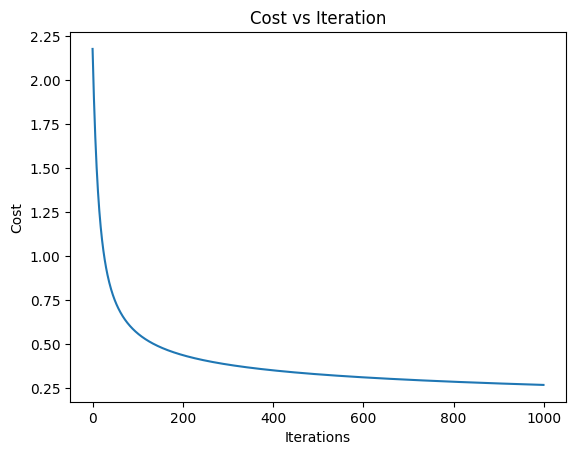

In [ ]:
plt.plot(cost_history)
plt.title("Cost vs Iteration")
plt.xlabel("Iterations")
plt.ylabel("Cost")
plt.show()

In [ ]:
y_pred = predict_softmax(X_test, W_opt, b_opt)

y_true = np.argmax(y_test, axis=1)

cm = confusion_matrix(y_true, y_pred)

precision = precision_score(y_true, y_pred, average="weighted")
recall = recall_score(y_true, y_pred, average="weighted")
f1 = f1_score(y_true, y_pred, average="weighted")

print(cm)
print("Precision:", precision)
print("Recall:", recall)
print("F1:", f1)

[[71  0  0  0  1  2  0  0  0  0]
 [ 0 97  0  0  0  1  0  0  1  0]
 [ 0  5 83  2  0  0  2  2  6  0]
 [ 0  0  3 98  0  7  0  1  3  0]
 [ 0  1  1  0 87  0  5  0  1  3]
 [ 1  0  0  6  1 59  1  0  4  0]
 [ 1  0  0  0  0  0 82  0  0  0]
 [ 2  2  2  0  1  0  0 99  0  1]
 [ 0  4  2  2  1  2  2  0 71  0]
 [ 1  0  1  0  3  0  0  3  1 81]]
Precision: 0.9018422590458862
Recall: 0.9009793253536452
F1: 0.9005882500640007
